# Laboratorio 9 - Task 1: beta-VAE sobre Fashion-MNIST

La idea central es entrenar la misma arquitectura VAE con $\beta\in\{0.1,1,10\}$ y medir cómo cambia el compromiso entre reconstrucción e información latente.

## Registro de uso de IA

- **Prompt utilizado:** `Ayúdame a crear una base o esqueleto para hacer el Task 1`
- **Por qué fue útil:** organizó la carga de datos, las fórmulas del VAE y las verificaciones en celdas reproducibles.

## Explicación Inicial Conceptos

En esta primera parte del laboratorio se implementa y analiza un Autoencoder Variacional (VAE) 
- es un modelo de aprendizaje profundo que pertenece a la familia de los modelos generativos. Su objetivo es aprender una representación latente de los datos de entrada, que permita generar nuevas muestras similares a las observadas. En particular, se estudia la variante $\beta$-VAE, que introduce un parámetro $\beta$ para controlar el balance entre la calidad de reconstrucción y la regularización del espacio latente.

Estamos utilizando el conjunto Fashion-MNIST con el objetivo de estudiar cómo cambia el comportamiento del modelo al modificar el parámetro $\beta$, que controla el balance entre la calidad de *reconstrucción* y la *regularización* del espacio latente.

Para ello, se entrenan tres modelos con:
-  $\beta = 0.1$
- $\beta = 1$ 
- $\beta = 10$ 

A partir de estos modelos se evalúan las curvas de reconstrucción y divergencia KL, la organización del espacio latente, la capacidad de generación de nuevas imágenes y las interpolaciones entre ejemplos. Por último, se comparan cuantitativamente los resultados mediante métricas como error de reconstrucción, KL en bits y nitidez, con el objetivo de entender el efecto que tiene $\beta$ sobre la información contenida en la representación latente y sobre la calidad visual de las imágenes generadas.


## 0. Preparación

La semilla queda fijada y reportada para que todos puedan reproducir la misma corrida.

In [19]:
from pathlib import Path
import math
import random
import time

import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

SEED = 3045
BATCH_SIZE = 128
LATENT_DIM = 2
EPOCHS = 20
LR = 1e-3
BETA_VALUES = [0.1, 1.0, 10.0]

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data"
CHECKPOINT_DIR = ROOT / "checkpoints" / "task1"
OUTPUT_DIR = ROOT / "outputs" / "task1"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()
print(f"Semilla: {SEED}")
print(f"Dispositivo: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Semilla: 3045
Dispositivo: cpu
PyTorch: 2.14.0+cpu


## 1. Task 1.1 - Configuración Experimental 

`ToTensor()` convierte los píxeles de 0-255 a `float` en $[0,1]$. No usamos `random_split`: el enunciado pide explícitamente tomar **los últimos 5,000** ejemplos del conjunto de entrenamiento como validación.

In [20]:
transform = transforms.ToTensor()

full_train = datasets.FashionMNIST(
    DATA_DIR, train=True, download=True, transform=transform
)
test_set = datasets.FashionMNIST(
    DATA_DIR, train=False, download=True, transform=transform
)

train_set = Subset(full_train, range(0, 55_000))
val_set = Subset(full_train, range(55_000, 60_000))


def make_train_loader(seed: int = SEED) -> DataLoader:
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(
        train_set,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )


val_loader = DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

x_batch, y_batch = next(iter(val_loader))
print("train / val / test:", len(train_set), len(val_set), len(test_set))
print("forma del lote:", tuple(x_batch.shape), tuple(y_batch.shape))
print("rango de píxeles:", float(x_batch.min()), float(x_batch.max()))
assert len(train_set) == 55_000 and len(val_set) == 5_000
assert x_batch.shape[1:] == (1, 28, 28)
assert 0.0 <= x_batch.min() and x_batch.max() <= 1.0

train / val / test: 55000 5000 10000
forma del lote: (128, 1, 28, 28) (128,)
rango de píxeles: 0.0 1.0


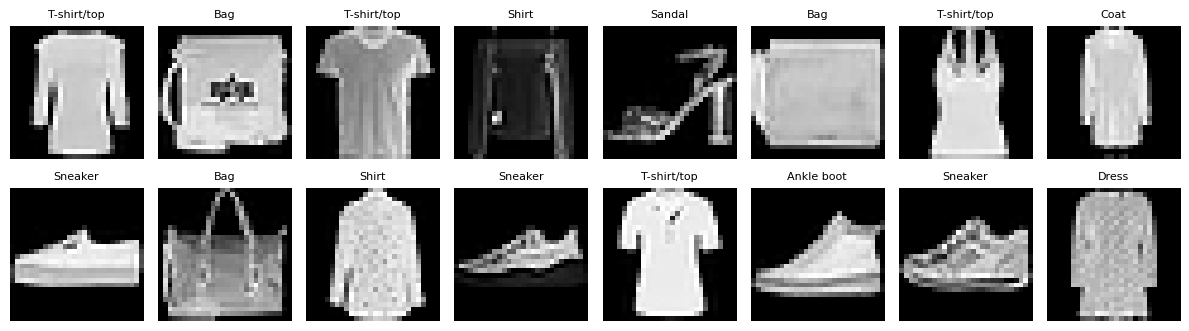

In [21]:
labels = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

fig, axes = plt.subplots(2, 8, figsize=(12, 3.5))
for ax, image, target in zip(axes.flat, x_batch[:16], y_batch[:16]):
    ax.imshow(image.squeeze(0), cmap="gray", vmin=0, vmax=1)
    ax.set_title(labels[int(target)], fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Task 1.2 - Implementación del VAE y entrenamiento

El encoder produce $\mu$ y $\log\sigma^2$. La reparametrización se escribe directamente:

$$z=\mu+\exp(\tfrac12\log\sigma^2)\odot\epsilon,\qquad \epsilon\sim\mathcal N(0,I).$$

La KL cerrada por imagen, sumada en las dos dimensiones latentes, es

$$D_{KL}(q\|p)=-\frac12\sum_j\left(1+\log\sigma_j^2-\mu_j^2-\sigma_j^2\right).$$

La reconstrucción se suma sobre los 784 píxeles y luego se promedia sobre el lote. Esta convención evita cambiar accidentalmente la escala relativa de reconstrucción y KL.

In [22]:
class VAE(nn.Module):
    def __init__(self, latent_dim: int = LATENT_DIM):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 400),
            nn.ReLU(),
        )
        self.mu_head = nn.Linear(400, latent_dim)
        self.logvar_head = nn.Linear(400, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 28 * 28),
            nn.Sigmoid(),
        )

    def encode(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        h = self.encoder(x)
        return self.mu_head(h), self.logvar_head(h)

    def reparameterize(
        self, mu: torch.Tensor, logvar: torch.Tensor
    ) -> torch.Tensor:
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)
        return mu + std * epsilon

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        return self.decoder(z).view(-1, 1, 28, 28)

    def forward(self, x: torch.Tensor):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


def vae_loss(
    x_hat: torch.Tensor,
    x: torch.Tensor,
    mu: torch.Tensor,
    logvar: torch.Tensor,
    beta: float,
):
    reconstruction = (x - x_hat).pow(2).flatten(1).sum(dim=1)
    kl = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum(dim=1)
    total = reconstruction + beta * kl
    return total.mean(), reconstruction.mean(), kl.mean()


model_check = VAE().to(DEVICE)
with torch.no_grad():
    x_hat, mu, logvar = model_check(x_batch[:8].to(DEVICE))
    loss, recon, kl = vae_loss(x_hat, x_batch[:8].to(DEVICE), mu, logvar, beta=1.0)
print("formas:", tuple(x_hat.shape), tuple(mu.shape), tuple(logvar.shape))
print("prueba de pérdida:", float(loss), float(recon), float(kl))

formas: (8, 1, 28, 28) (8, 2) (8, 2)
prueba de pérdida: 127.55101013183594 127.52595520019531 0.02504236251115799


In [23]:
def run_epoch(model, loader, beta: float, optimizer=None):
    training = optimizer is not None
    model.train(training)
    totals = {"loss": 0.0, "recon": 0.0, "kl": 0.0, "n": 0}

    for x, _ in loader:
        x = x.to(DEVICE, non_blocking=True)
        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            x_hat, mu, logvar = model(x)
            loss, recon, kl = vae_loss(x_hat, x, mu, logvar, beta)
            if training:
                loss.backward()
                optimizer.step()

        n = x.size(0)
        totals["loss"] += loss.item() * n
        totals["recon"] += recon.item() * n
        totals["kl"] += kl.item() * n
        totals["n"] += n

    return {key: totals[key] / totals["n"] for key in ("loss", "recon", "kl")}


def train_one_beta(beta: float):
    # Reiniciamos semilla y orden de lotes para una comparación justa entre betas.
    set_seed(SEED)
    model = VAE().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    train_loader = make_train_loader(SEED)
    history = {name: [] for name in (
        "train_loss", "train_recon", "train_kl",
        "val_loss", "val_recon", "val_kl",
    )}

    for epoch in range(1, EPOCHS + 1):
        train_metrics = run_epoch(model, train_loader, beta, optimizer)
        val_metrics = run_epoch(model, val_loader, beta)
        for key, value in train_metrics.items():
            history[f"train_{key}"].append(value)
        for key, value in val_metrics.items():
            history[f"val_{key}"].append(value)
        print(
            f"beta={beta:>4} | epoca={epoch:02d}/{EPOCHS} | "
            f"val_recon={val_metrics['recon']:.4f} | val_KL={val_metrics['kl']:.4f}"
        )

    torch.save(model.state_dict(), CHECKPOINT_DIR / f"vae_beta_{beta}.pt")
    return model, history

### Entrenamiento

In [24]:
RUN_TRAINING = True

models = {}
histories = {}
if RUN_TRAINING:
    for beta in BETA_VALUES:
        models[beta], histories[beta] = train_one_beta(beta)
else:
    print("Entrenamiento omitido. Cambia RUN_TRAINING a True para la corrida oficial.")

beta= 0.1 | epoca=01/20 | val_recon=27.1949 | val_KL=9.6267
beta= 0.1 | epoca=02/20 | val_recon=25.4404 | val_KL=9.4014
beta= 0.1 | epoca=03/20 | val_recon=24.7997 | val_KL=9.4693
beta= 0.1 | epoca=04/20 | val_recon=24.0926 | val_KL=9.1814
beta= 0.1 | epoca=05/20 | val_recon=23.7974 | val_KL=8.6587
beta= 0.1 | epoca=06/20 | val_recon=23.6174 | val_KL=8.9134
beta= 0.1 | epoca=07/20 | val_recon=23.4592 | val_KL=8.4772
beta= 0.1 | epoca=08/20 | val_recon=23.2691 | val_KL=8.8370
beta= 0.1 | epoca=09/20 | val_recon=23.1717 | val_KL=8.6020
beta= 0.1 | epoca=10/20 | val_recon=22.8426 | val_KL=9.0910
beta= 0.1 | epoca=11/20 | val_recon=22.7997 | val_KL=8.5924
beta= 0.1 | epoca=12/20 | val_recon=22.6530 | val_KL=8.5619
beta= 0.1 | epoca=13/20 | val_recon=22.5880 | val_KL=8.8350
beta= 0.1 | epoca=14/20 | val_recon=22.5134 | val_KL=8.9680
beta= 0.1 | epoca=15/20 | val_recon=22.4934 | val_KL=8.3643
beta= 0.1 | epoca=16/20 | val_recon=22.4039 | val_KL=8.4404
beta= 0.1 | epoca=17/20 | val_recon=22.3

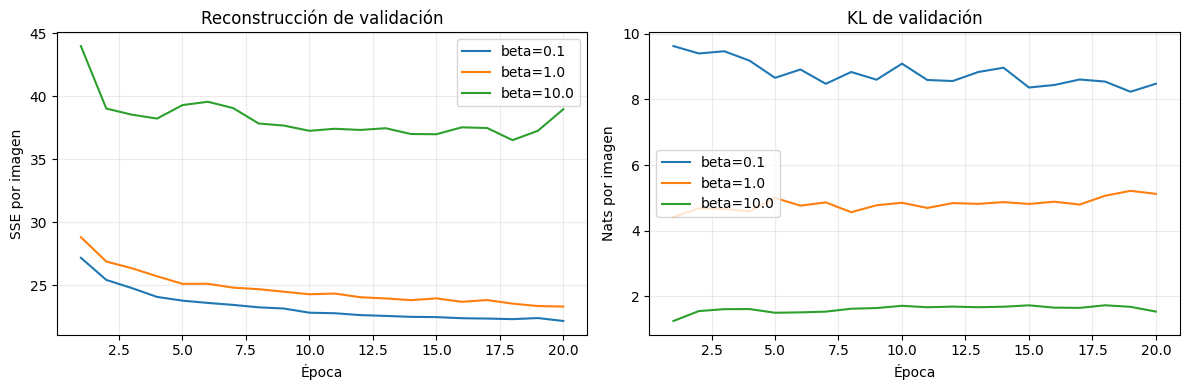

In [25]:
if histories:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs_axis = range(1, EPOCHS + 1)
    for beta in BETA_VALUES:
        axes[0].plot(epochs_axis, histories[beta]["val_recon"], label=f"beta={beta}")
        axes[1].plot(epochs_axis, histories[beta]["val_kl"], label=f"beta={beta}")
    axes[0].set(title="Reconstrucción de validación", xlabel="Época", ylabel="SSE por imagen")
    axes[1].set(title="KL de validación", xlabel="Época", ylabel="Nats por imagen")
    for ax in axes:
        ax.grid(alpha=0.25)
        ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "task1_2_curvas_validacion.png", dpi=180)
    plt.show()

## Task 1.3 - Análisis Visual del espacio latente y generación de muestras

Las celdas siguientes usan únicamente resultados de los tres modelos entrenados. Cada figura se guarda también en `outputs/task1/`. 
En este análisis podremos observar cómo el parámetro $\beta$ afecta la organización del espacio latente y la calidad de las imágenes generadas. Además de las visualizaciones, se calculan métricas cuantitativas como el error de reconstrucción, la divergencia KL y la nitidez de las imágenes generadas, para comparar los modelos entrenados con diferentes valores de $\beta$.

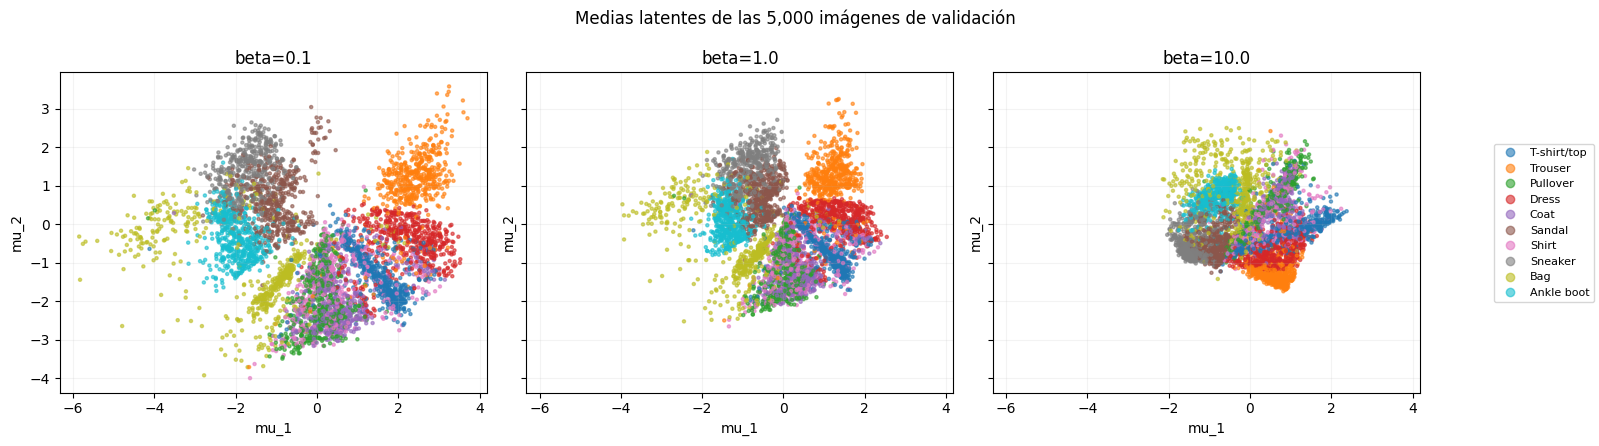

In [26]:
@torch.no_grad()
def collect_latents(model, loader):
    model.eval()
    mus, targets = [], []
    for x, y in loader:
        mu, _ = model.encode(x.to(DEVICE))
        mus.append(mu.cpu())
        targets.append(y)
    return torch.cat(mus), torch.cat(targets)


if models:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True, sharey=True)
    for ax, beta in zip(axes, BETA_VALUES):
        mu_all, y_all = collect_latents(models[beta], val_loader)
        points = ax.scatter(
            mu_all[:, 0], mu_all[:, 1], c=y_all, cmap="tab10", s=5, alpha=0.6
        )
        ax.set(title=f"beta={beta}", xlabel="mu_1", ylabel="mu_2")
        ax.grid(alpha=0.15)
    handles, _ = points.legend_elements(num=10)
    fig.legend(handles, labels, loc="center right", fontsize=8)
    fig.suptitle("Medias latentes de las 5,000 imágenes de validación")
    plt.tight_layout(rect=(0, 0, 0.9, 1))
    plt.savefig(OUTPUT_DIR / "task1_3a_latentes.png", dpi=180)
    plt.show()

Se puede notar que con respecto a la reconstrucción, el modelo con $\beta=0.1$ logra un error de reconstrucción más bajo, lo que indica que es capaz de capturar mejor los detalles de las imágenes originales. Sin embargo, esto viene a costa de una mayor divergencia KL, lo que sugiere que el espacio latente no está tan regularizado y puede contener más información redundante.

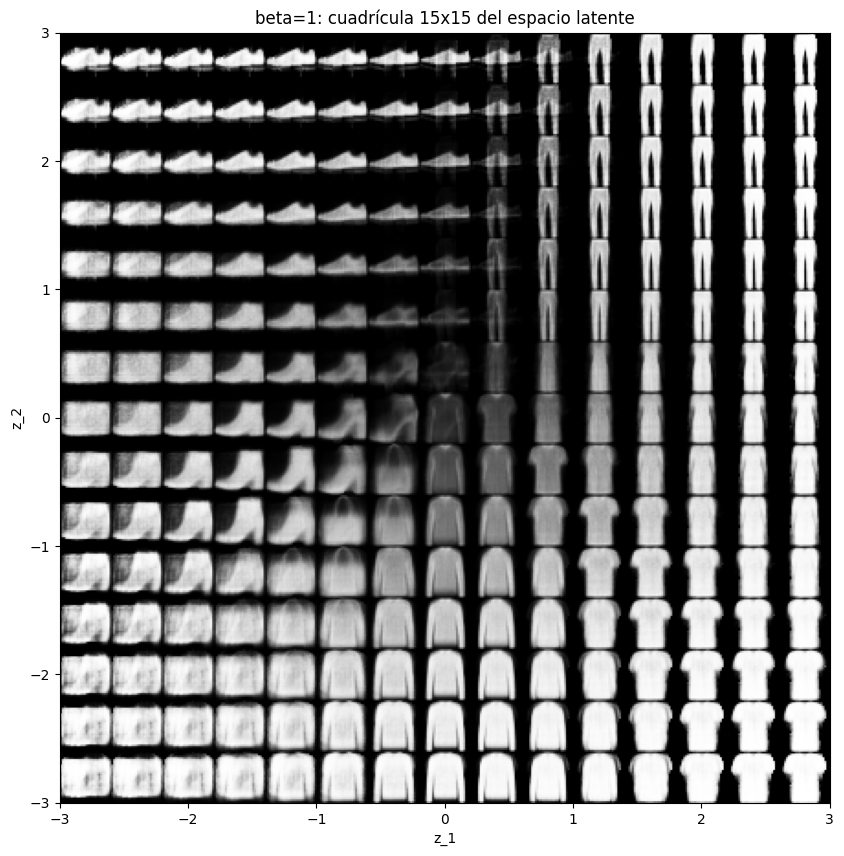

In [27]:
@torch.no_grad()
def decode_latent_grid(model, low=-3.0, high=3.0, steps=15):
    model.eval()
    axis = torch.linspace(low, high, steps)
    yy, xx = torch.meshgrid(axis.flip(0), axis, indexing="ij")
    z = torch.stack([xx.flatten(), yy.flatten()], dim=1).to(DEVICE)
    return model.decode(z).cpu().view(steps, steps, 28, 28)


if models:
    grid = decode_latent_grid(models[1.0])
    canvas = torch.cat([torch.cat(list(row), dim=1) for row in grid], dim=0)
    plt.figure(figsize=(10, 10))
    plt.imshow(canvas, cmap="gray", vmin=0, vmax=1, extent=[-3, 3, -3, 3])
    plt.title("beta=1: cuadrícula 15x15 del espacio latente")
    plt.xlabel("z_1")
    plt.ylabel("z_2")
    plt.savefig(OUTPUT_DIR / "task1_3b_cuadricula_latente.png", dpi=180, bbox_inches="tight")
    plt.show()

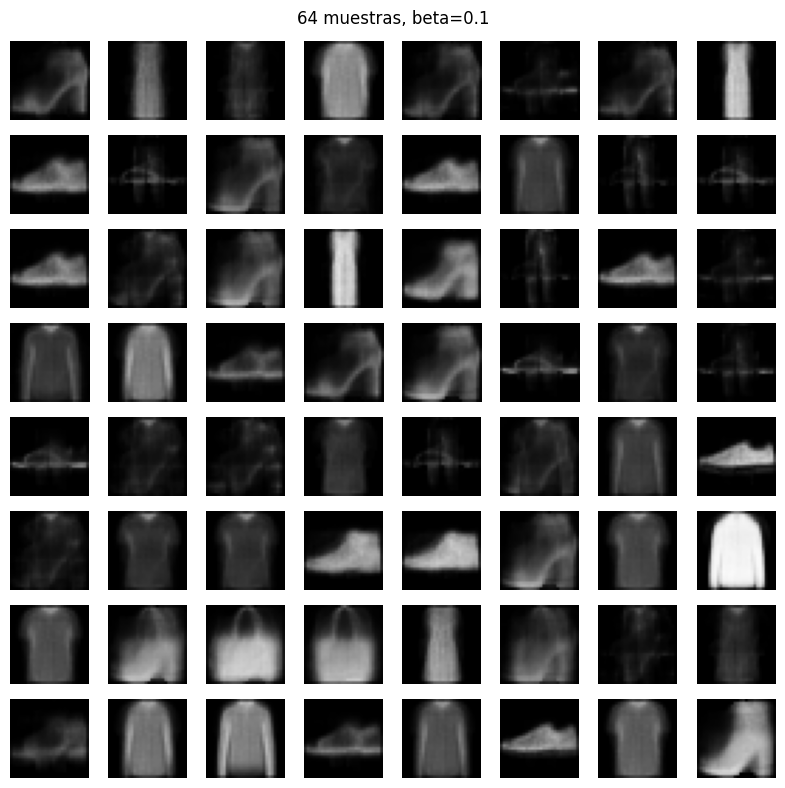

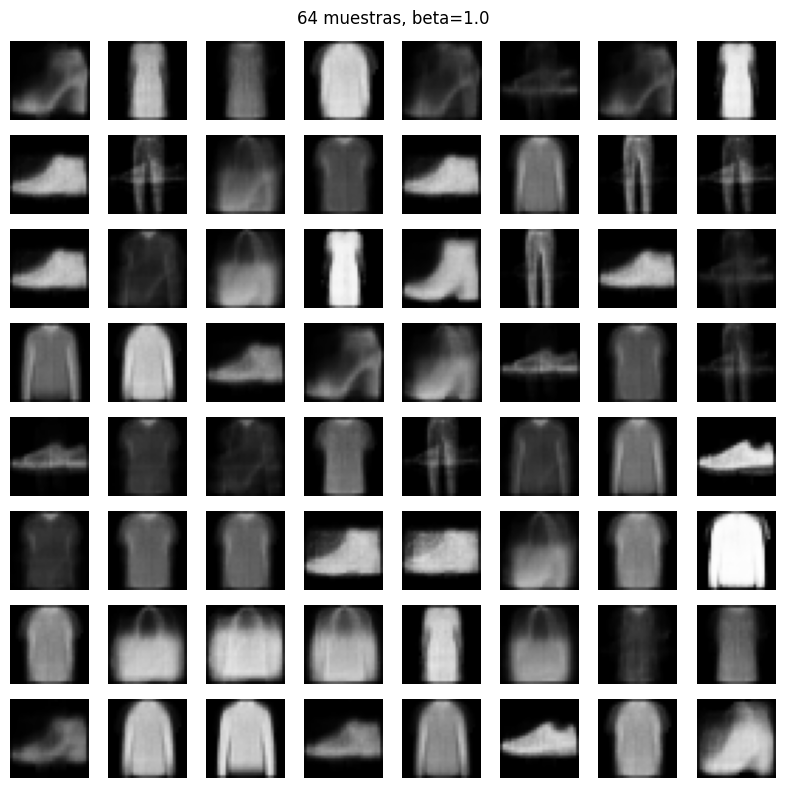

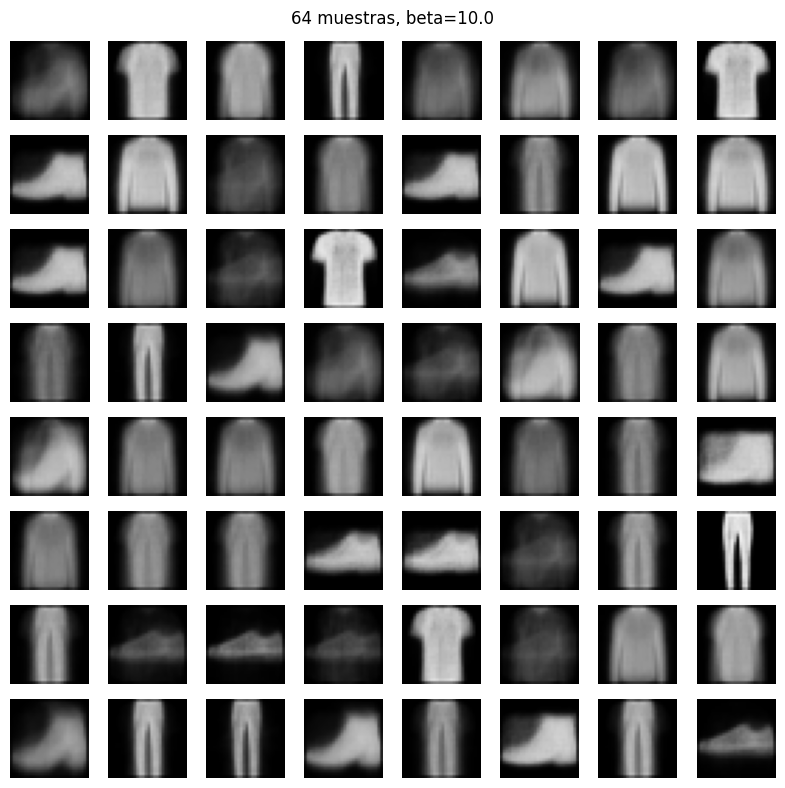

In [28]:
@torch.no_grad()
def generate(model, n: int, seed: int = SEED):
    model.eval()
    generator = torch.Generator(device=DEVICE).manual_seed(seed)
    z = torch.randn(n, LATENT_DIM, generator=generator, device=DEVICE)
    return model.decode(z).cpu()


def show_8x8(images, title, output_name):
    fig, axes = plt.subplots(8, 8, figsize=(8, 8))
    for ax, image in zip(axes.flat, images[:64]):
        ax.imshow(image.squeeze(0), cmap="gray", vmin=0, vmax=1)
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / output_name, dpi=180)
    plt.show()


if models:
    for beta in BETA_VALUES:
        samples = generate(models[beta], 64, seed=SEED)
        show_8x8(samples, f"64 muestras, beta={beta}", f"task1_3c_beta_{beta}.png")

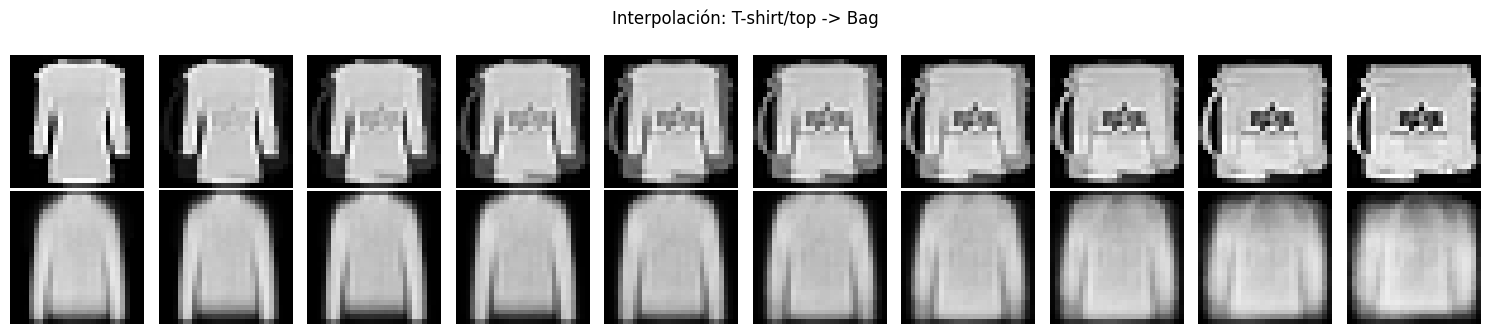

In [29]:
def find_two_classes(dataset):
    x_a, y_a = dataset[0]
    for i in range(1, len(dataset)):
        x_b, y_b = dataset[i]
        if y_b != y_a:
            return x_a, int(y_a), x_b, int(y_b)
    raise RuntimeError("No se encontraron dos clases distintas")


@torch.no_grad()
def compare_interpolations(model, dataset, intermediate_points=8):
    model.eval()
    x_a, y_a, x_b, y_b = find_two_classes(dataset)
    x_a_device = x_a.unsqueeze(0).to(DEVICE)
    x_b_device = x_b.unsqueeze(0).to(DEVICE)
    mu_a, _ = model.encode(x_a_device)
    mu_b, _ = model.encode(x_b_device)

    # 8 puntos intermedios + 2 extremos = 10 imágenes por fila.
    weights = torch.linspace(0, 1, intermediate_points + 2, device=DEVICE)
    pixel_path = torch.stack([(1 - w) * x_a + w * x_b for w in weights.cpu()])
    latent_z = torch.cat([(1 - w) * mu_a + w * mu_b for w in weights], dim=0)
    latent_path = model.decode(latent_z).cpu()
    return pixel_path, latent_path, y_a, y_b


if models:
    pixel_path, latent_path, y_a, y_b = compare_interpolations(models[1.0], val_set)
    fig, axes = plt.subplots(2, 10, figsize=(15, 3.4))
    for col in range(10):
        axes[0, col].imshow(pixel_path[col].squeeze(), cmap="gray", vmin=0, vmax=1)
        axes[1, col].imshow(latent_path[col].squeeze(), cmap="gray", vmin=0, vmax=1)
        axes[0, col].axis("off")
        axes[1, col].axis("off")
    axes[0, 0].set_ylabel("Píxeles")
    axes[1, 0].set_ylabel("Latente")
    fig.suptitle(f"Interpolación: {labels[y_a]} -> {labels[y_b]}")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "task1_3d_interpolaciones.png", dpi=180)
    plt.show()

En la interpolación entre una camiseta y una bolsa, la interpolación directa en píxeles genera imágenes intermedias que parecen una superposición de ambos objetos. En el punto medio todavía se observan simultáneamente características de la camiseta y de la bolsa. En cambio, la interpolación en el espacio latente produce una transición más suave y estructurada, ya que el decoder transforma puntos intermedios del espacio aprendido en imágenes que permanecen dentro de la distribución aprendida por el modelo.

La diferencia se debe a que la interpolación en píxeles combina intensidades independientemente de la estructura semántica de la imagen, mientras que la interpolación latente se realiza sobre representaciones comprimidas que contienen características aprendidas de las prendas.

## 4. Task 1.4 - Evaluación Cuantitativa e Interpretación 

Estas celdas producen la evidencia numérica. Después de ejecutarlas, reemplacen los marcadores de la última sección con observaciones específicas de sus tablas y figuras.

Para un decoder gaussiano con varianza fija $\sigma_x^2$, la parte dependiente de la reconstrucción en la ELBO negativa es

$$\frac{1}{2\sigma_x^2}\lVert x-\hat{x}\rVert^2 + D_{KL}.$$

Multiplicar toda la expresión por $2\sigma_x^2$ no cambia su óptimo y da

$$\lVert x-\hat{x}\rVert^2 + 2\sigma_x^2D_{KL}.$$

Al compararla con $\mathcal L_\beta=\lVert x-\hat{x}\rVert^2+\beta D_{KL}$ se obtiene $\beta=2\sigma_x^2$ y, por tanto, $\sigma_x^2=\beta/2$.

In [30]:
if histories:
    header = f"{'beta':>6} | {'Recon final':>12} | {'KL (nats)':>10} | {'KL (bits)':>10}"
    print(header)
    print("-" * len(header))
    for beta in BETA_VALUES:
        recon = histories[beta]["val_recon"][-1]
        kl_nats = histories[beta]["val_kl"][-1]
        kl_bits = kl_nats / math.log(2)
        print(f"{beta:6.1f} | {recon:12.4f} | {kl_nats:10.4f} | {kl_bits:10.4f}")
    print(f"Referencia log2(10): {math.log2(10):.4f} bits")

  beta |  Recon final |  KL (nats) |  KL (bits)
-----------------------------------------------
   0.1 |      22.1864 |     8.4781 |    12.2314
   1.0 |      23.3299 |     5.1227 |     7.3905
  10.0 |      38.9694 |     1.5345 |     2.2139
Referencia log2(10): 3.3219 bits


Al aumentar β, el término KL recibe un mayor peso y obliga a la distribución latente a acercarse más a la normal estándar. Esto se observa claramente en los resultados: la KL disminuye de 12.2314 bits para β=0.1 a 2.2139 bits para β=10. Sin embargo, esta mayor regularización tiene un costo en reconstrucción, ya que el error aumenta de 22.1864 a 38.9694. Para β=10, la KL se encuentra por debajo de los 3.3219 bits requeridos teóricamente para identificar una de diez clases, por lo que el código latente no dispone, en promedio, de suficiente capacidad informativa para codificar perfectamente la clase.

Este resultado coincide con el diagrama de dispersión de β=10, donde las clases ocupan una región mucho más compacta y presentan una superposición considerable. Aunque todavía existen zonas asociadas con determinadas clases, la separación es notablemente menor que para β=0.1 y β=1.0.

In [31]:
@torch.no_grad()
def verify_kl_monte_carlo(model, image, n_samples=100_000, seed=SEED):
    model.eval()
    x = image.unsqueeze(0).to(DEVICE)
    mu, logvar = model.encode(x)
    std = torch.exp(0.5 * logvar)

    generator = torch.Generator(device=DEVICE).manual_seed(seed)
    epsilon = torch.randn(n_samples, LATENT_DIM, generator=generator, device=DEVICE)
    z = mu + std * epsilon

    # log q(z|x) y log p(z), escritos sin torch.distributions.
    log_2pi = math.log(2 * math.pi)
    log_q = -0.5 * (log_2pi + logvar + (z - mu).pow(2) / logvar.exp()).sum(dim=1)
    log_p = -0.5 * (log_2pi + z.pow(2)).sum(dim=1)
    log_ratio = log_q - log_p

    mc = log_ratio.mean()
    standard_error = log_ratio.std(unbiased=True) / math.sqrt(n_samples)
    closed = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum()
    relative_error = (mc - closed).abs() / closed.abs().clamp_min(1e-12)
    z_score = (mc - closed).abs() / standard_error.clamp_min(1e-12)
    return {
        "closed_form": closed.item(),
        "monte_carlo": mc.item(),
        "relative_error": relative_error.item(),
        "standard_error": standard_error.item(),
        "error_in_standard_errors": z_score.item(),
    }


if models:
    kl_check = verify_kl_monte_carlo(models[1.0], val_set[0][0])
    for key, value in kl_check.items():
        print(f"{key}: {value:.8f}")

closed_form: 5.08353710
monte_carlo: 5.08533287
relative_error: 0.00035325
standard_error: 0.00316382
error_in_standard_errors: 0.56759548


Para verificar la expresión cerrada de la divergencia KL se tomó una imagen de validación con el modelo β=1 y se comparó el valor analítico con una estimación Monte Carlo utilizando 10^5 muestras. La KL cerrada fue 5.08353710, mientras que la estimación Monte Carlo fue 5.08533287. El error relativo fue únicamente 0.00035325, equivalente aproximadamente a 0.57 errores estándar. Por lo tanto, la diferencia observada es completamente compatible con la variabilidad estadística esperada de una estimación Monte Carlo de este tamaño y confirma numéricamente la implementación de la fórmula cerrada.

In [32]:
def horizontal_sharpness(images: torch.Tensor) -> torch.Tensor:
    # Magnitud media |x[:,:,:,1:] - x[:,:,:,:-1]|.
    return (images[..., 1:] - images[..., :-1]).abs().mean()


def first_images(dataset, n: int):
    return torch.stack([dataset[i][0] for i in range(n)])


if models:
    real_images = first_images(val_set, 1_000)
    sharpness_rows = [("reales", horizontal_sharpness(real_images).item(), None)]
    for beta in BETA_VALUES:
        generated = generate(models[beta], 1_000, seed=SEED + int(beta * 10))
        sharpness_rows.append(
            (f"VAE beta={beta}", horizontal_sharpness(generated).item(), beta / 2)
        )

    print(f"{'conjunto':>16} | {'nitidez':>10} | {'sigma_x^2=beta/2':>18}")
    print("-" * 52)
    for name, sharpness, sigma2 in sharpness_rows:
        sigma_text = "-" if sigma2 is None else f"{sigma2:.3f}"
        print(f"{name:>16} | {sharpness:10.6f} | {sigma_text:>18}")

        conjunto |    nitidez |   sigma_x^2=beta/2
----------------------------------------------------
          reales |   0.089146 |                  -
    VAE beta=0.1 |   0.031240 |              0.050
    VAE beta=1.0 |   0.046194 |              0.500
   VAE beta=10.0 |   0.044091 |              5.000


La nitidez promedio de las imágenes reales fue 0.089146, mientras que las generadas por los VAE obtuvieron 0.031240 para β=0.1, 0.046194 para β=1 y 0.044091 para β=10. Todos los valores generados son considerablemente menores que el de las imágenes reales, lo cual confirma cuantitativamente el aspecto borroso observado en las muestras.

A partir de la forma de la ELBO negativa, la pérdida utilizada corresponde a una varianza del decoder 

$\sigma_x^2=\beta/2$.

 Por tanto, aumentar $\beta$ equivale a asumir una mayor varianza de observación y a dar relativamente más peso a la regularización KL que a la reconstrucción exacta. Esto favorece representaciones latentes más regulares, pero permite que el decoder tolere mayores desviaciones de píxel, contribuyendo a reconstrucciones y muestras más suaves.


Aunque el efecto general de β se interpreta mediante el compromiso entre reconstrucción y regularización, la medida de nitidez no crece de forma estrictamente monótona con β en esta corrida. β=1 obtuvo la mayor nitidez entre los modelos generativos, con 0.046194. Esto muestra que la nitidez depende no solo del valor de β, sino también de cómo queda organizado el espacio latente y de las muestras generadas desde el prior.


# Conclusiones Task 1 

Podemos notar que los experimentos muestran claramente el compromiso controlado por $\beta$ en el VAE. Con $\beta=0.1$ se obtuvo el menor error de reconstrucción (22.1864), pero una KL elevada de 12.2314 bits, esto nos dice que el espacio latente conserva una mayor cantidad de información sobre las entradas.

Ya cuando aumentamos $\beta$, la KL disminuyó y el espacio latente se volvió más compacto y regularizado, pero el error de reconstrucción aumentó. El caso más extremo fue $\beta=10$, con una KL de 2.2139 bits y un error de reconstrucción de 38.9694.

Para $\beta=10$, la KL se encuentra por debajo de $\log_2(10)\approx3.3219$ bits. Esto sugiere que el código latente no contiene, en promedio, suficiente información para identificar perfectamente una de las diez clases. Esta conclusión es consistente con el diagrama de dispersión, donde se observa una mayor superposición entre las clases para $\beta=10$.

La verificación Monte Carlo confirmó la implementación de la divergencia KL. El valor cerrado fue 5.08353710 y la estimación con $10^5$ muestras fue 5.08533287, con un error relativo de 0.00035325. La diferencia corresponde únicamente a aproximadamente 0.57 errores estándar, por lo que es compatible con la variabilidad esperada del método Monte Carlo.

La cuadrícula del espacio latente de $\beta=1$ mostró regiones asociadas a distintos tipos de prendas y transiciones suaves entre ellas. Las zonas ubicadas entre regiones correspondientes a diferentes clases generaron imágenes más ambiguas, lo que refleja que el decoder interpola continuamente incluso en puntos que no corresponden exactamente a ejemplos reales. De forma similar, la interpolación entre una camiseta y una bolsa mostró que la interpolación en píxeles produce una superposición directa de ambas imágenes, mientras que la interpolación latente genera una transición más estructurada.
